# Esse é o tratamento inicial de 1 arquivo


## Carregando Arquivo
*Estou carregando pelo pandas e não pelo numpy. Por que? Porque eu quero!*

In [1]:
import pandas as pd
import numpy as np
import filter as ft
import utils2 as ut2
import utils as ut

from configuration_new import Configuration

cfg = Configuration()

arquivo="data/02010001_still.txt"

column_labels = ['Fp1', 'Fpz', 'Fp2']

data = pd.read_csv(arquivo, sep=" ", header=None, names=column_labels)

data_np = np.transpose(data.to_numpy().astype(float)) #Convertendo os dados para np.ndarray


### Corrige o sinal dos valores
Os valores são lidos em microvolts e depois passam por um conversor A/D (Analógico-Digital) de **24 bits** (importante verificar esse valor conforme os dados utilizados) que vai converter para um valor inteiro entre 0 e 2^24. Portanto, valores que são maiores que 2^23 são números negativos e menores que isso são positivos.


In [2]:
data_np, changed_values = ft.fix_integer_wraparound(data_np)

### Verificando se os dados estão de acordo com o esperado


In [ ]:
data_np = np.ascontiguousarray(data_np)
if ft.is_data_shape_ok(data_np)!= True:
    print('DEU MERDA')

print('ARQUIVO ESTÁ NO TAMANHO ESPERADO')


(3, 301740)
ARQUIVO ESTÁ NO TAMANHO ESPERADO


### Filtrando o sinal

In [4]:
data_np = ft.subtract_mean_value(data_np) 

data_np = ft.notch_filter(data_np) # Filtrando o ruído do circuito elétrico (default = 50Hz)

data_np = ft.band_pass_filter(data_np) # Filtro passa faixa (default=[1,40])

cut_size = int( round( cfg.sampling_frequency * cfg.exclusion_time_window ))

data_np = ft.cut_array_edges(data_np, cut_size)







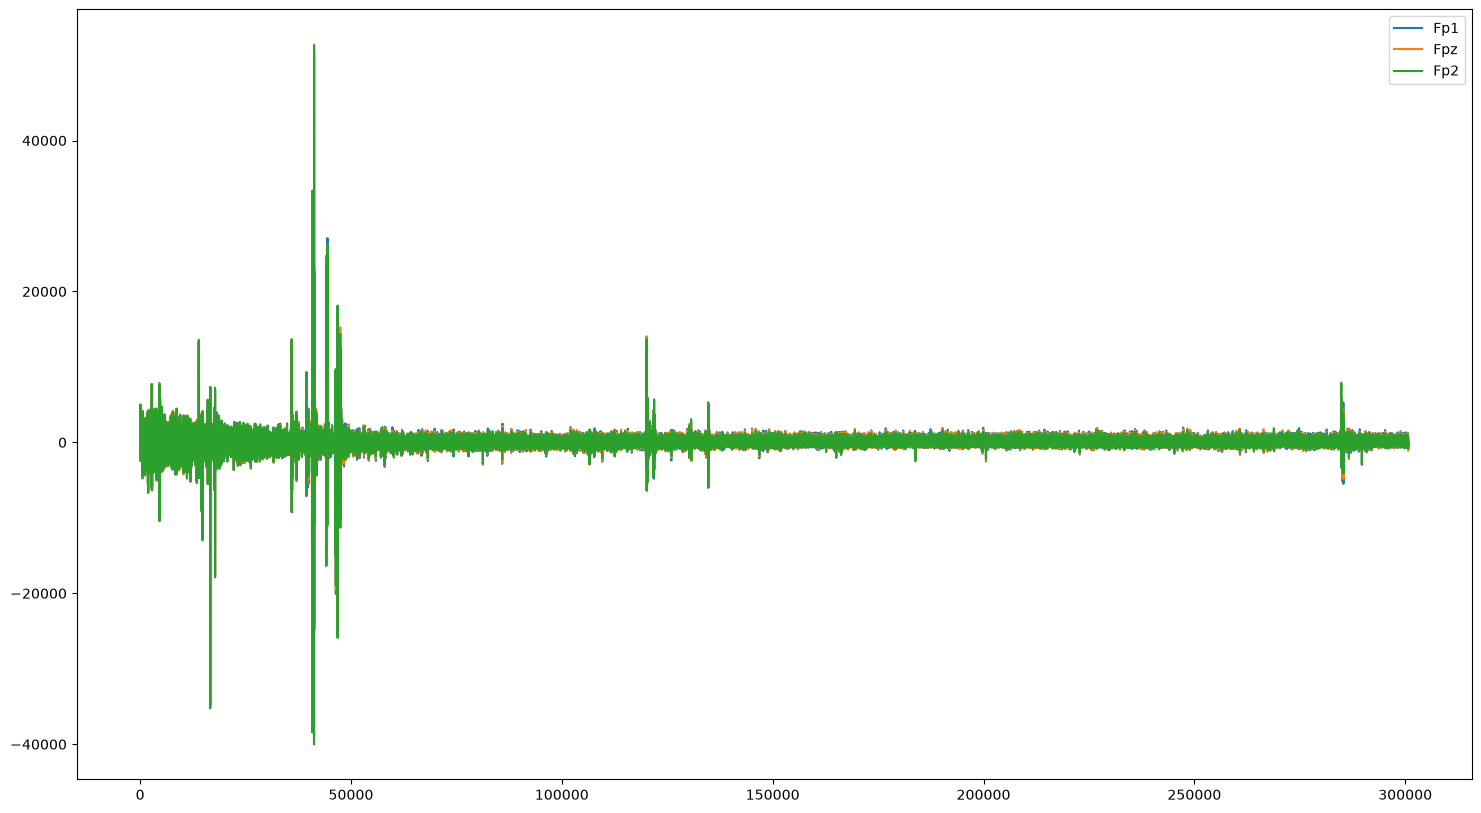

In [5]:
data = pd.DataFrame(np.transpose(data_np), columns=column_labels)
data.plot(figsize=(18,10));


## Calculando o perfil temporal de cada bloco